# Machine Learning Model Training - Projet Stations 5G

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time 

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

pd.set_option('display.max_columns', 100)
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print("Libraries imported.")

Libraries imported.


## 2. Load Processed Data

In [2]:
try:
    df_train = pd.read_csv('../data/processed/train_processed.csv')
    print(f"Training data loaded successfully. Shape: {df_train.shape}")
except FileNotFoundError:
    print("Error: train_processed.csv not found. Make sure the file is in the correct directory.")

if 'df_train' in locals():
    print("\nData Info:")
    df_train.info()
    print("\nData Head:")
    print(df_train.head())

Training data loaded successfully. Shape: (1491, 3458)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1491 entries, 0 to 1490
Columns: 3458 entries, ID to f_3455
dtypes: float64(3456), int64(2)
memory usage: 39.3 MB

Data Head:
     ID  target        f_0        f_1        f_2        f_3        f_4  \
0     0       0 -42.948462 -34.199885 -30.691196 -45.281565 -27.159948   
1     1       0 -29.737236 -25.753736 -37.949008 -48.141273 -34.831778   
2    10       2 -28.809412 -21.332285 -44.010719 -48.457581 -50.332964   
3   100       0 -24.033439 -37.224449 -41.048676 -45.728247 -27.487252   
4  1000       0 -43.919513 -33.837200 -47.267240 -45.747744 -24.110065   

         f_5        f_6        f_7        f_8        f_9       f_10  \
0 -37.036769 -27.196869 -46.880042 -55.278376 -40.201860 -39.392719   
1 -41.446983 -38.129590 -44.418079 -55.591961 -31.067240 -37.614454   
2 -37.401645 -47.338483 -51.549376 -44.177276 -40.349714 -48.311229   
3 -34.885894 -41.107078 -48.

## 3. Data Review and Preparation


Target Variable Distribution (target):
target
0    81.086519
2     9.456740
1     9.456740
Name: proportion, dtype: float64


C:\Users\redh0\AppData\Local\Temp\ipykernel_15540\2410839521.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df_train, palette='viridis')


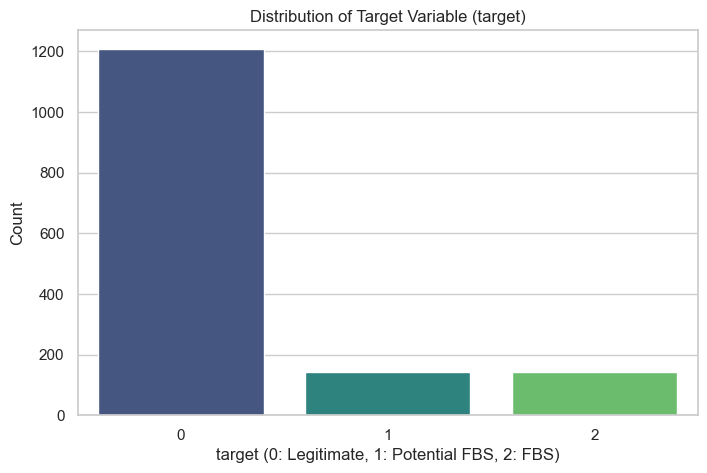


Features shape (X): (1491, 3456)
Target shape (y): (1491,)

Feature Description (sample):
               f_0          f_1          f_2          f_3          f_4  \
count  1491.000000  1491.000000  1491.000000  1491.000000  1491.000000   
mean    -36.025564   -31.790284   -42.053352   -43.198133   -33.594962   
std       7.526132     8.278178     6.915052     7.170975     8.335229   
min     -49.546726   -58.185262   -55.155300   -56.979272   -60.080805   
25%     -41.034316   -35.412184   -46.693774   -48.075347   -36.904316   
50%     -37.726149   -31.305910   -43.456727   -44.526252   -33.104941   
75%     -33.083523   -26.894991   -39.379352   -40.322942   -29.115439   
max      -1.629375    -5.376032    -4.717370   -11.923473     0.203893   

               f_5          f_6          f_7          f_8          f_9  \
count  1491.000000  1491.000000  1491.000000  1491.000000  1491.000000   
mean    -35.821412   -38.591200   -47.680546   -50.421536   -36.818454   
std       7.265872  

In [3]:
if df_train is not None:
    print("\nTarget Variable Distribution (target):")
    target_distribution = df_train['target'].value_counts(normalize=True) * 100
    print(target_distribution)
    
    plt.figure(figsize=(8, 5))
    sns.countplot(x='target', data=df_train, palette='viridis')
    plt.title('Distribution of Target Variable (target)')
    plt.xlabel('target (0: Legitimate, 1: Potential FBS, 2: FBS)')
    plt.ylabel('Count')
    plt.show()
    
    X = df_train.drop(['target', 'ID'], axis=1)
    y = df_train['target']
    
    print(f"\nFeatures shape (X): {X.shape}")
    print(f"Target shape (y): {y.shape}")
    
    print("\nFeature Description (sample):")
    print(X.describe())

else:
    print("DataFrame 'df_train' or column 'target' not available.")

## 4. Split Data into Training and Validation Sets

In [4]:
if 'X' in locals() and 'y' in locals():
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, 
        test_size=0.2,
        random_state=42,
        stratify=y
    )
    
    print(f"Training set shape: X_train={X_train.shape}, y_train={y_train.shape}")
    print(f"Validation set shape: X_val={X_val.shape}, y_val={y_val.shape}")
    
    print("\nOriginal distribution:")
    print(y.value_counts(normalize=True) * 100)
    print("\nTraining set distribution:")
    print(y_train.value_counts(normalize=True) * 100)
    print("\nValidation set distribution:")
    print(y_val.value_counts(normalize=True) * 100)
else:
    print("Features (X) and target (y) not defined. Cannot split data.")

Training set shape: X_train=(1192, 3456), y_train=(1192,)
Validation set shape: X_val=(299, 3456), y_val=(299,)

Original distribution:
target
0    81.086519
2     9.456740
1     9.456740
Name: proportion, dtype: float64

Training set distribution:
target
0    81.040268
2     9.479866
1     9.479866
Name: proportion, dtype: float64

Validation set distribution:
target
0    81.270903
1     9.364548
2     9.364548
Name: proportion, dtype: float64


## 5. Model Training and Evaluation

In [5]:
def evaluate_model(model_name, model, X_train, y_train, X_val, y_val):
    print(f"--- Evaluating {model_name} ---")
    start_time = time.time()
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_val)
    
    end_time = time.time()
    print(f"Training and Prediction time: {end_time - start_time:.2f} seconds")
    
    accuracy = accuracy_score(y_val, y_pred)
    weighted_f1 = f1_score(y_val, y_pred, average='weighted')
    cm = confusion_matrix(y_val, y_pred)
    cr = classification_report(y_val, y_pred)
    
    print(f"\nAccuracy: {accuracy:.4f}")
    print(f"Weighted F1-Score: {weighted_f1:.4f}")
    print("\nClassification Report:")
    print(cr)
    
    print("Confusion Matrix:")
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1, 2], yticklabels=[0, 1, 2])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()
    
    return {'model': model_name, 'accuracy': accuracy, 'weighted_f1': weighted_f1, 'trained_model': model}

results = []

### 5.1 Logistic Regression

--- Evaluating Logistic Regression ---
Training and Prediction time: 0.21 seconds

Accuracy: 0.9933
Weighted F1-Score: 0.9933

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       243
           1       1.00      0.93      0.96        28
           2       0.93      1.00      0.97        28

    accuracy                           0.99       299
   macro avg       0.98      0.98      0.98       299
weighted avg       0.99      0.99      0.99       299

Confusion Matrix:


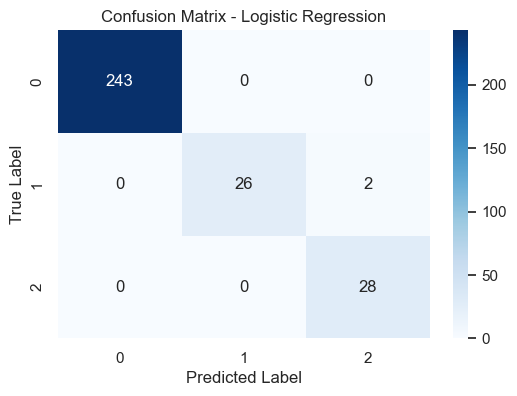

In [6]:
if 'X_train' in locals():
    lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000) # Increased max_iter for convergence
    lr_results = evaluate_model("Logistic Regression", lr_model, X_train, y_train, X_val, y_val)
    results.append(lr_results)
else:
    print("Training data not available.")

### 5.2 Random Forest

--- Evaluating Random Forest ---
Training and Prediction time: 2.39 seconds

Accuracy: 0.9833
Weighted F1-Score: 0.9831

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       243
           1       1.00      0.82      0.90        28
           2       0.85      1.00      0.92        28

    accuracy                           0.98       299
   macro avg       0.95      0.94      0.94       299
weighted avg       0.99      0.98      0.98       299

Confusion Matrix:


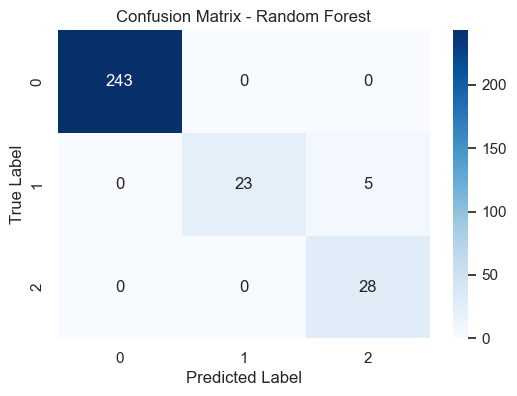

In [7]:
if 'X_train' in locals():
    rf_model = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
    rf_results = evaluate_model("Random Forest", rf_model, X_train, y_train, X_val, y_val)
    results.append(rf_results)
else:
    print("Training data not available.")

### 5.3 XGBoost Classifier

--- Evaluating XGBoost ---


C:\Users\redh0\.conda\envs\Privacy_Preserving_Face_Recognition_Project\Lib\site-packages\xgboost\core.py:158: UserWarning: [01:37:10] WARNING: C:\b\abs_90_bwj_86a\croot\xgboost-split_1724073762025\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Training and Prediction time: 10.64 seconds

Accuracy: 0.9900
Weighted F1-Score: 0.9899

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       243
           1       1.00      0.89      0.94        28
           2       0.90      1.00      0.95        28

    accuracy                           0.99       299
   macro avg       0.97      0.96      0.96       299
weighted avg       0.99      0.99      0.99       299

Confusion Matrix:


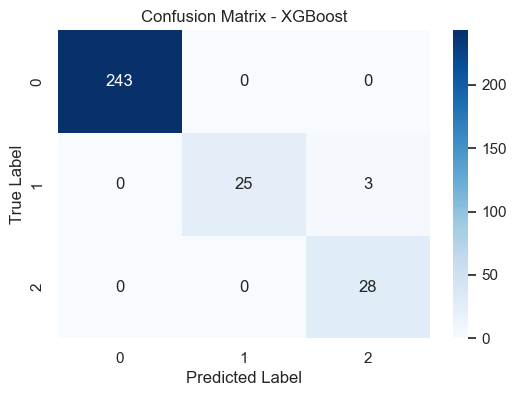

In [8]:
if 'X_train' in locals():
    xgb_model = xgb.XGBClassifier(objective='multi:softmax',
                                num_class=3,
                                eval_metric='mlogloss',
                                use_label_encoder=False,
                                random_state=42)
    
    xgb_results = evaluate_model("XGBoost", xgb_model, X_train, y_train, X_val, y_val)
    results.append(xgb_results)
else:
    print("Training data not available.")

## 6. Results Summary

In [9]:
if results:
    results_df = pd.DataFrame(results).drop(columns=['trained_model'])
    results_df = results_df.sort_values(by='weighted_f1', ascending=False)
    
    print("Model Performance Summary (Validation Set):")
    print(results_df)
    
    best_model_name = results_df.iloc[0]['model']
    best_f1_score = results_df.iloc[0]['weighted_f1']
    print(f"\nBest performing model: {best_model_name} with Weighted F1-Score: {best_f1_score:.4f}")
else:
    print("No model results to summarize.")

Model Performance Summary (Validation Set):
                 model  accuracy  weighted_f1
0  Logistic Regression  0.993311     0.993302
2              XGBoost  0.989967     0.989938
1        Random Forest  0.983278     0.983143

Best performing model: Logistic Regression with Weighted F1-Score: 0.9933


## 7. Hyperparameter Tuning


--- Hyperparameter Tuning Example (Logistic Regression) ---
Starting Grid Search for Logistic Regression...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters found: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Weighted F1-Score (CV): 0.9882

--- Evaluating Tuned Logistic Regression ---
--- Evaluating Tuned Logistic Regression ---
Training and Prediction time: 0.36 seconds

Accuracy: 0.9933
Weighted F1-Score: 0.9933

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       243
           1       1.00      0.93      0.96        28
           2       0.93      1.00      0.97        28

    accuracy                           0.99       299
   macro avg       0.98      0.98      0.98       299
weighted avg       0.99      0.99      0.99       299

Confusion Matrix:


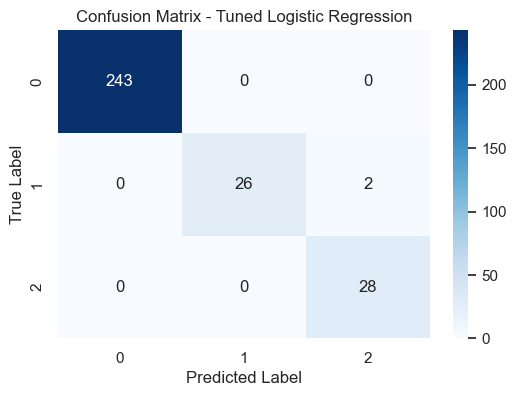

In [10]:
if 'X_train' in locals() and 'Logistic Regression' in [res['model'] for res in results]:
    print("\n--- Hyperparameter Tuning Example (Logistic Regression) ---")

    param_grid_lr = {
        'C': [0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs'],
        'max_iter': [1000, 2000, 3000]
    }

    cv_strat = StratifiedKFold(n_splits=3)

    lr_base = LogisticRegression(class_weight='balanced', random_state=42)

    grid_search_lr = GridSearchCV(estimator=lr_base,
                                  param_grid=param_grid_lr,
                                  cv=cv_strat,
                                  n_jobs=-1,
                                  scoring='f1_weighted',
                                  verbose=2)

    print("Starting Grid Search for Logistic Regression...")

    try:
        grid_search_lr.fit(X_train, y_train)

        print(f"Best Parameters found: {grid_search_lr.best_params_}")
        print(f"Best Weighted F1-Score (CV): {grid_search_lr.best_score_:.4f}")

        best_lr_model = grid_search_lr.best_estimator_

        print("\n--- Evaluating Tuned Logistic Regression ---")
        tuned_lr_results = evaluate_model("Tuned Logistic Regression", best_lr_model, X_train, y_train, X_val, y_val)
        results.append(tuned_lr_results)

    except ValueError as e:
        print(f"An error occurred during GridSearchCV fitting: {e}")
        print("Please ensure X_train contains only the features the model was originally trained on (e.g., no 'ID' column if it was removed).")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

else:
    print("Cannot run tuning example: Training data or Logistic Regression results missing.")

## 8. Final Model Selection and Test Set Prediction

In [11]:
if results:
    results_df_final = pd.DataFrame(results).sort_values(by='weighted_f1', ascending=False)
    best_model_entry = next((item for item in results if item['model'] == results_df_final.iloc[0]['model']), None)
    
    if best_model_entry:
        final_model_name = best_model_entry['model']
        
        final_model = best_model_entry['trained_model'] 
        print(f"Selected final model: {final_model_name}")
    else:
        print("Could not retrieve the best model from results.")
else:
    print("No model results available to select a final model.")

Selected final model: Logistic Regression


## 9. Générer les prédictions pour le jeu de test

In [12]:
import pandas as pd
import os

test_processed_path = '../data/processed/test_processed.csv'

try:
    df_test_processed = pd.read_csv(test_processed_path)
    print(f"Test file loaded: {test_processed_path}, Shape: {df_test_processed.shape}")

    if 'final_model' not in locals() or 'final_model_name' not in locals():
        print("Error: Final model ('final_model' or 'final_model_name') is not defined. Select or train a final model.")
    elif 'X_train' not in locals() and 'X' not in locals():
         print("Error: Training columns (X_train or X) are not available for checking correspondence.")
    else:
        submissions_dir = '../submissions/'
        safe_model_name = final_model_name.lower().replace(' ', '_')
        
        submission_filename = f"{safe_model_name}_submission.csv"
        submission_path = os.path.join(submissions_dir, submission_filename)

        os.makedirs(submissions_dir, exist_ok=True)
        print(f"Submission path set to: {submission_path}")

        if 'ID' in df_test_processed.columns:
            test_ids = df_test_processed['ID']
            X_test = df_test_processed.drop('ID', axis=1)
            print("'ID' column found and separated.")
        else:
            test_ids = pd.Series(range(len(df_test_processed)))
            X_test = df_test_processed
            print("Warning: 'ID' column not found in test file. Using sequential indices.")

        if 'X_train' in locals():
             train_feature_cols = X_train.columns
        elif 'X' in locals():
             train_feature_cols = X.columns
        else:
             raise NameError("Could not determine training columns.")

        print(f"Expected number of feature columns (without ID): {len(train_feature_cols)}")
        print(f"Number of columns in X_test (without ID): {X_test.shape[1]}")

        try:
            X_test_aligned = X_test[train_feature_cols]
            print(f"Number of columns in X_test after alignment: {X_test_aligned.shape[1]}")

            print(f"Predicting with model: {final_model_name}")
            test_predictions = final_model.predict(X_test_aligned)
            print(f"Predictions generated. Shape: {test_predictions.shape}")

            submission_df = pd.DataFrame({'ID': test_ids, 'target': test_predictions})

            submission_df = submission_df.sort_values(by='ID', ascending=True)
            print("Submission file sorted by ID.")

            submission_df.to_csv(submission_path, index=False)
            print(f"Submission file saved: {submission_path}")

        except KeyError as e:
             print(f"Missing column error during final alignment: {e}.")
             print(f"Expected columns: {list(train_feature_cols)}")
             print(f"Columns present in X_test: {list(X_test.columns)}")


except FileNotFoundError:
    print(f"Error: File {test_processed_path} not found.")
except NameError as e:
     print(f"Undefined variable error: {e}. Ensure 'final_model', 'final_model_name' and training data are available.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Test file loaded: ../data/processed/test_processed.csv, Shape: (120, 3457)
Submission path set to: ../submissions/logistic_regression_submission.csv
'ID' column found and separated.
Expected number of feature columns (without ID): 3456
Number of columns in X_test (without ID): 3456
Number of columns in X_test after alignment: 3456
Predicting with model: Logistic Regression
Predictions generated. Shape: (120,)
Submission file sorted by ID.
Submission file saved: ../submissions/logistic_regression_submission.csv
